# AI Adoption Readiness — 6-Model Comparison (Group Split by SME only)

Group-based split/CV by `SME_Name` only — no SME's employees ever appear in both train and test. This is the realistic evaluation (tests generalization to unseen businesses), so the random-split version has been removed.

**Updated in this version:** SMOTE class-imbalance handling on the training partition, RandomizedSearchCV hyperparameter tuning (5-fold, 40 candidates per model), and SHAP-based explainability for the final selected model.

**Model features:** only the 17 original Employee (E1–E10) and Managerial (M1–M9) factor scores are used to train the models. `Employee_Count` and `Age_Range` are demographic attributes, not factors, and are excluded from the feature set.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (GroupShuffleSplit, StratifiedGroupKFold, StratifiedKFold,
                                      RandomizedSearchCV, cross_val_score, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


## 2. Load & Clean the Data

In [2]:
DATA_PATH = "Merged_Employee_Manager_Factor_Scores.xlsx"   # <-- replace with your own path if needed

df = pd.read_excel(DATA_PATH, sheet_name='Merged_Data')

def clean_employee_count(v):
    if isinstance(v, str) and '-' in v:
        a, b = v.split('-')
        return (float(a) + float(b)) / 2
    return float(v)

df['Employee_Count'] = df['Employee_Count'].apply(clean_employee_count)

AGE_ORDER = ['18–25', '26–35', '36–45', '46–55', '56+']
df['Age_Range_ord'] = df['Age_Range'].apply(lambda x: AGE_ORDER.index(x))

# NOTE: Employee_Count and Age_Range_ord are kept here only as demographic/reference
# columns for descriptive purposes. They are demographic attributes, NOT model factors,
# and are deliberately EXCLUDED from feature_cols below — only the 17 Employee (E) and
# Managerial (M) factor scores are used to train the models.

print("Shape:", df.shape, " | Unique SMEs:", df['SME_Name'].nunique())
df.head()


Shape: (316, 24)  | Unique SMEs: 21


,Name,Age_Range,SME_Name,SME_Name_As_Reported,Sector,Employee_Count,E1 PerceivedUsefulness,E2 PerceivedEaseOfUse,E3 TechnicalLiteracy,E5 TrustInAI,...,E10 UserParticipation,M1 TopMgmtSupport,M2 FinancialCapability,M3 ITInfrastructure,M4 DataQualityStrategy,M5 InnovationCulture,M6 CompetitivePressure,M8 RegulatoryEnvironment,M9 VendorReadiness,Age_Range_ord
0,Ajith,36–45,Athula Distributors,Athula Distributors,Consumer/product distribution,17.0,4.5,5.0,5.0,4.0,...,4.0,3.5,4.5,3.5,2.0,3.5,4.5,4.5,3.5,2
1,Akash,26–35,Athula Distributors,Athula Distributors,Consumer/product distribution,17.0,4.0,3.5,3.5,2.5,...,4.0,3.5,4.5,3.5,2.0,3.5,4.5,4.5,3.5,1
2,Athula,26–35,Athula Distributors,Athula Distributors,Consumer/product distribution,17.0,4.0,5.0,4.0,4.0,...,4.0,3.5,4.5,3.5,2.0,3.5,4.5,4.5,3.5,1
3,Chathurika,18–25,Athula Distributors,Athula Distributors,Consumer/product distribution,17.0,4.5,5.0,5.0,4.5,...,4.5,3.5,4.5,3.5,2.0,3.5,4.5,4.5,3.5,0
4,Kausalya,56+,Athula Distributors,Athula Distributors,Consumer/product distribution,17.0,4.0,2.0,2.0,3.0,...,5.0,3.5,4.5,3.5,2.0,3.5,4.5,4.5,3.5,4


## 3. Feature Scaling & Priority Weighting

Priority factors — **M2, M3, M4, E2, E3, E7** — are weighted ×1.6 after standardization.

In [3]:
factor_cols = [
    'E1 PerceivedUsefulness', 'E2 PerceivedEaseOfUse', 'E3 TechnicalLiteracy', 'E5 TrustInAI',
    'E6 FearOfJobLoss', 'E7 Complexity', 'E8 JobRelevance', 'E9 SocioTechnicalAlignment', 'E10 UserParticipation',
    'M1 TopMgmtSupport', 'M2 FinancialCapability', 'M3 ITInfrastructure', 'M4 DataQualityStrategy',
    'M5 InnovationCulture', 'M6 CompetitivePressure', 'M8 RegulatoryEnvironment', 'M9 VendorReadiness',
]
feature_cols = factor_cols  # ONLY the 17 Employee (E) + Managerial (M) factors are used as model features

X_raw = df[feature_cols].copy()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=feature_cols, index=df.index)

PRIORITY_COLS = ['E2 PerceivedEaseOfUse', 'E3 TechnicalLiteracy', 'E7 Complexity',
                 'M2 FinancialCapability', 'M3 ITInfrastructure', 'M4 DataQualityStrategy']
PRIORITY_WEIGHT = 1.6

X_weighted = X_scaled.copy()
for c in PRIORITY_COLS:
    X_weighted[c] = X_weighted[c] * PRIORITY_WEIGHT


## 4. K-Means Clustering (k=3) → Target Label

In [4]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_id = kmeans.fit_predict(X_weighted)
df['Cluster'] = cluster_id

df['OverallScore'] = df[factor_cols].mean(axis=1)
cluster_order = df.groupby('Cluster')['OverallScore'].mean().sort_values().index.tolist()
label_map = {cluster_order[0]: 'Low', cluster_order[1]: 'Medium', cluster_order[2]: 'High'}
df['AI_Readiness_Level'] = df['Cluster'].map(label_map)

print(df['AI_Readiness_Level'].value_counts())
df.groupby('AI_Readiness_Level')['OverallScore'].agg(['mean', 'count']).loc[['Low', 'Medium', 'High']]


AI_Readiness_Level
Medium    167
High       90
Low        59
Name: count, dtype: int64


,mean,count
AI_Readiness_Level,,
Low,3.229811,59
Medium,3.675062,167
High,3.794771,90


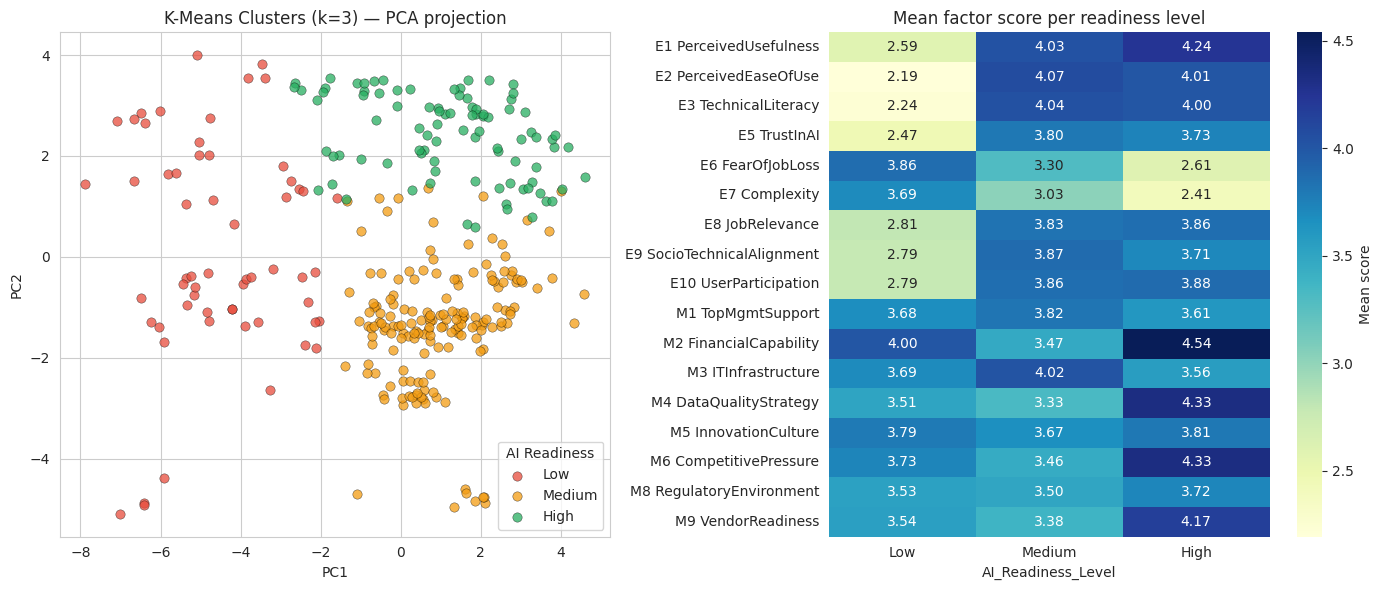

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_weighted)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = {'Low': '#e74c3c', 'Medium': '#f39c12', 'High': '#27ae60'}
for lvl in ['Low', 'Medium', 'High']:
    mask = df['AI_Readiness_Level'] == lvl
    axes[0].scatter(coords[mask, 0], coords[mask, 1], label=lvl, s=45,
                     color=palette[lvl], edgecolor='black', alpha=0.75, linewidth=0.3)
axes[0].set_title('K-Means Clusters (k=3) — PCA projection')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(title='AI Readiness')
cluster_profile = df.groupby('AI_Readiness_Level')[feature_cols].mean().loc[['Low', 'Medium', 'High']]
sns.heatmap(cluster_profile.T, annot=True, fmt='.2f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': 'Mean score'})
axes[1].set_title('Mean factor score per readiness level')
plt.tight_layout(); plt.show()


## 5. Group-Based Train/Test Split (by SME)

`GroupShuffleSplit` on `SME_Name` — no SME's employees are ever split across train and test.

In [6]:
le = LabelEncoder()
y = le.fit_transform(df['AI_Readiness_Level'])
X = X_weighted.values
class_names = le.classes_
groups = df['SME_Name'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Train SMEs:", df['SME_Name'].iloc[train_idx].nunique(), " Test SMEs:", df['SME_Name'].iloc[test_idx].nunique())
print("Overlap SMEs between train/test:", len(set(df['SME_Name'].iloc[train_idx]) & set(df['SME_Name'].iloc[test_idx])))
print("Train distribution:", pd.Series(y_train).value_counts().to_dict())
print("Test distribution:", pd.Series(y_test).value_counts().to_dict())


Train size: 225  Test size: 91
Train SMEs: 15  Test SMEs: 6
Overlap SMEs between train/test: 0
Train distribution: {2: 123, 0: 58, 1: 44}
Test distribution: {2: 44, 0: 32, 1: 15}


## 5b. Class Imbalance Handling (SMOTE)

SMOTE is applied to the **training partition only**, and only if the imbalance ratio between the largest and smallest class exceeds 1.5. The held-out test set (`X_test`, `y_test`) is never touched, so test performance is still measured on real, unsynthesized employees.

In [7]:
train_counts = Counter(y_train)
imbalance_ratio = max(train_counts.values()) / min(train_counts.values())
print("Train class counts:", train_counts, " | Imbalance ratio:", round(imbalance_ratio, 2))

if imbalance_ratio > 1.5:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("SMOTE applied. New train class counts:", Counter(y_train_res))
else:
    X_train_res, y_train_res = X_train, y_train
    print("Imbalance ratio <= 1.5 — SMOTE not applied.")


Train class counts: Counter({np.int64(2): 123, np.int64(0): 58, np.int64(1): 44})  | Imbalance ratio: 2.8
SMOTE applied. New train class counts: Counter({np.int64(2): 123, np.int64(1): 123, np.int64(0): 123})


## 6. Model Hyperparameter Search Spaces

In [8]:
param_distributions = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs'],
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'criterion': ['gini', 'entropy'],
    },
    'Random Forest': {
        'n_estimators': [200, 300, 400, 600],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
    },
    'SVM (RBF)': {
        'C': [0.01, 0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    },
    'XGBoost': {
        'n_estimators': [200, 300, 400],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    },
    'ANN (MLP)': {
        'hidden_layer_sizes': [(32,16), (64,32), (128,64), (128,64,32)],
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'learning_rate_init': [0.001, 0.005, 0.01],
        'batch_size': [16, 32, 64],
    },
}

base_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(random_state=RANDOM_STATE),
    'SVM (RBF)':           SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'XGBoost':             XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    'ANN (MLP)':           MLPClassifier(max_iter=3000, early_stopping=True, random_state=RANDOM_STATE),
}
list(base_models.keys())


['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'SVM (RBF)',
 'XGBoost',
 'ANN (MLP)']

## 7. Tune, Train, Evaluate, Group Cross-Validate

- **Tuning:** `RandomizedSearchCV` (5-fold `StratifiedKFold`, 40 candidate configurations, scored on accuracy), fit on the SMOTE-resampled training data.
- **Primary:** Accuracy, Precision, Recall, F1-score (weighted), Confusion Matrix — evaluated on the untouched test set.
- **Additional:** 5-fold `StratifiedGroupKFold` CV Accuracy/F1, ROC-AUC (multiclass OvR, from out-of-fold CV probabilities), Train vs Test accuracy (train accuracy uses the original, unresampled training data).

In [9]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []
confusion_matrices = {}
best_estimators = {}
test_predictions = {}

for name, base_model in base_models.items():
    print(f"\n=== Tuning {name} ===")
    search = RandomizedSearchCV(
        base_model, param_distributions[name],
        n_iter=40, scoring='accuracy', cv=inner_cv,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train_res, y_train_res)
    print("Best params:", search.best_params_)
    best_estimators[name] = search.best_estimator_

    model = clone(search.best_estimator_)
    model.fit(X_train_res, y_train_res)

    y_pred_test  = model.predict(X_test)
    y_pred_train = model.predict(X_train)     # evaluated on the ORIGINAL, unresampled train data
    test_predictions[name] = y_pred_test

    acc  = accuracy_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred_test, labels=np.arange(len(class_names)))
    confusion_matrices[name] = cm

    train_acc = accuracy_score(y_train, y_pred_train)

    cv_acc = cross_val_score(clone(search.best_estimator_), X, y, cv=sgkf, groups=groups, scoring='accuracy')
    cv_f1  = cross_val_score(clone(search.best_estimator_), X, y, cv=sgkf, groups=groups, scoring='f1_weighted')

    y_proba_oof = cross_val_predict(clone(search.best_estimator_), X, y, cv=sgkf, groups=groups, method='predict_proba')
    roc_auc = roc_auc_score(y, y_proba_oof, multi_class='ovr', average='weighted')

    results.append({
        'Model': name,
        'Best Params': search.best_params_,
        'Test Accuracy': acc,
        'Precision (weighted)': prec,
        'Recall (weighted)': rec,
        'F1-score (weighted)': f1,
        'Train Accuracy': train_acc,
        'CV Accuracy (5-fold, mean)': cv_acc.mean(),
        'CV Accuracy (5-fold, std)': cv_acc.std(),
        'CV F1 (5-fold, mean)': cv_f1.mean(),
        'CV F1 (5-fold, std)': cv_f1.std(),
        'ROC-AUC (OvR, weighted)': roc_auc,
    })

results_df = pd.DataFrame(results).sort_values('CV F1 (5-fold, mean)', ascending=False).reset_index(drop=True)
results_df.drop(columns=['Best Params']).round(4)



=== Tuning Logistic Regression ===
Best params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}

=== Tuning Decision Tree ===
Best params: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy'}

=== Tuning Random Forest ===
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}

=== Tuning SVM (RBF) ===
Best params: {'gamma': 0.01, 'C': 0.1}

=== Tuning XGBoost ===
Best params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}

=== Tuning ANN (MLP) ===
Best params: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (128, 64), 'batch_size': 32, 'alpha': 0.001}


,Model,Test Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),Train Accuracy,"CV Accuracy (5-fold, mean)","CV Accuracy (5-fold, std)","CV F1 (5-fold, mean)","CV F1 (5-fold, std)","ROC-AUC (OvR, weighted)"
0,Logistic Regression,0.9341,0.9445,0.9341,0.9345,1.0000,0.9881,0.0162,0.9879,0.0167,0.9992
1,ANN (MLP),1.0000,1.0000,1.0000,1.0000,0.9956,0.9351,0.0498,0.9354,0.0504,0.9951
2,SVM (RBF),1.0000,1.0000,1.0000,1.0000,1.0000,0.9010,0.0969,0.9015,0.0944,1.0000
3,XGBoost,0.8352,0.8642,0.8352,0.8387,1.0000,0.8788,0.0908,0.8782,0.0897,0.9571
4,Random Forest,0.8462,0.8742,0.8462,0.8490,1.0000,0.8417,0.1134,0.8391,0.1151,0.9637
5,Decision Tree,0.7033,0.7007,0.7033,0.7018,1.0000,0.8147,0.0971,0.8092,0.0947,0.8420


### Confusion matrices — all 6 models

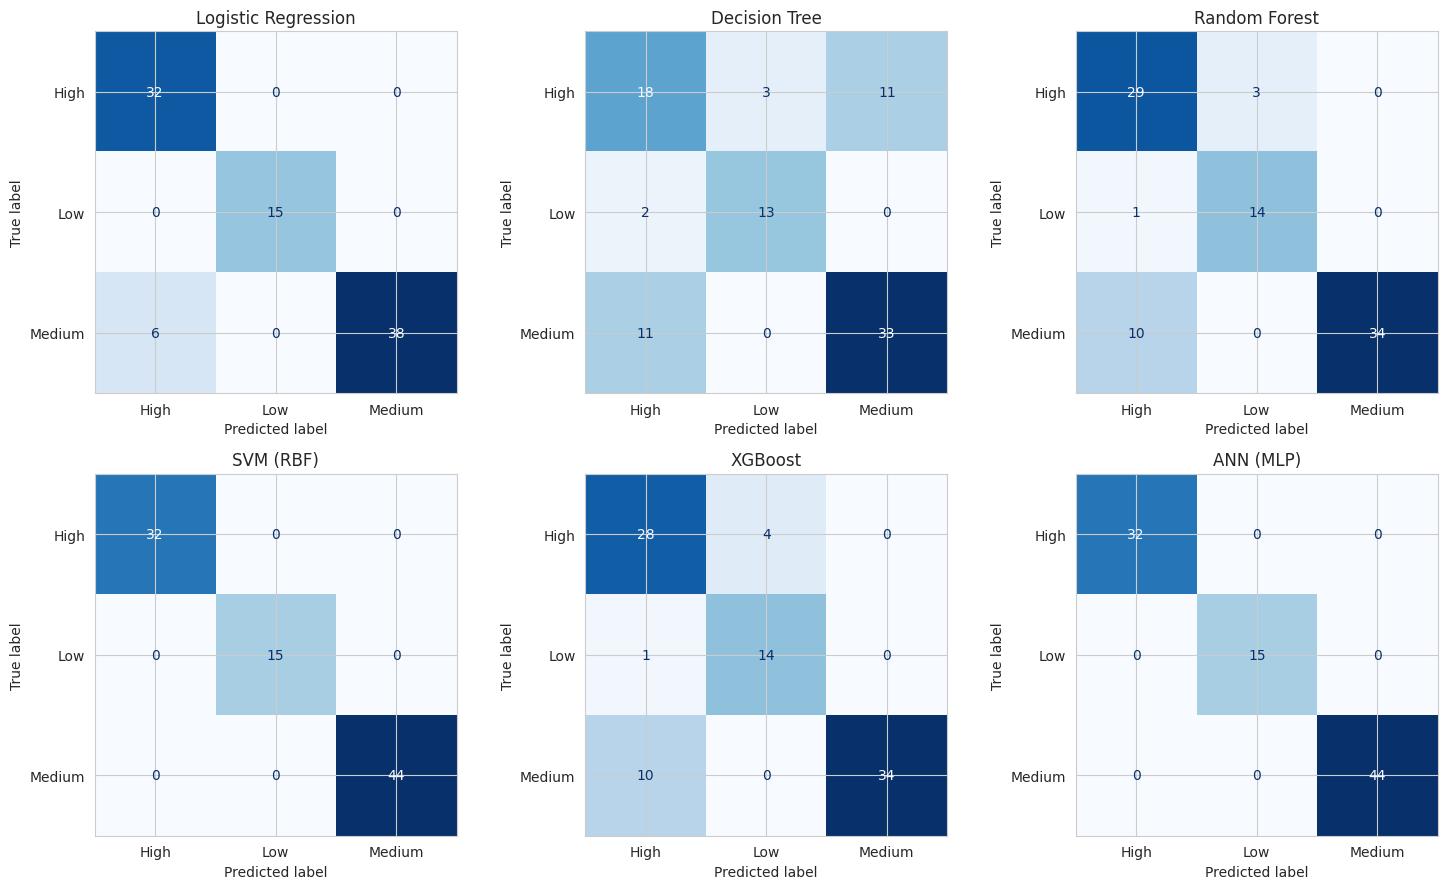

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, cm) in zip(axes.ravel(), confusion_matrices.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout(); plt.show()


### Per-model classification report (test set)

In [11]:
for name in base_models.keys():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, test_predictions[name], target_names=class_names, zero_division=0))



=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.84      1.00      0.91        32
         Low       1.00      1.00      1.00        15
      Medium       1.00      0.86      0.93        44

    accuracy                           0.93        91
   macro avg       0.95      0.95      0.95        91
weighted avg       0.94      0.93      0.93        91


=== Decision Tree ===
              precision    recall  f1-score   support

        High       0.58      0.56      0.57        32
         Low       0.81      0.87      0.84        15
      Medium       0.75      0.75      0.75        44

    accuracy                           0.70        91
   macro avg       0.71      0.73      0.72        91
weighted avg       0.70      0.70      0.70        91


=== Random Forest ===
              precision    recall  f1-score   support

        High       0.72      0.91      0.81        32
         Low       0.82      0.93      0.88        15


## 8. Model Comparison

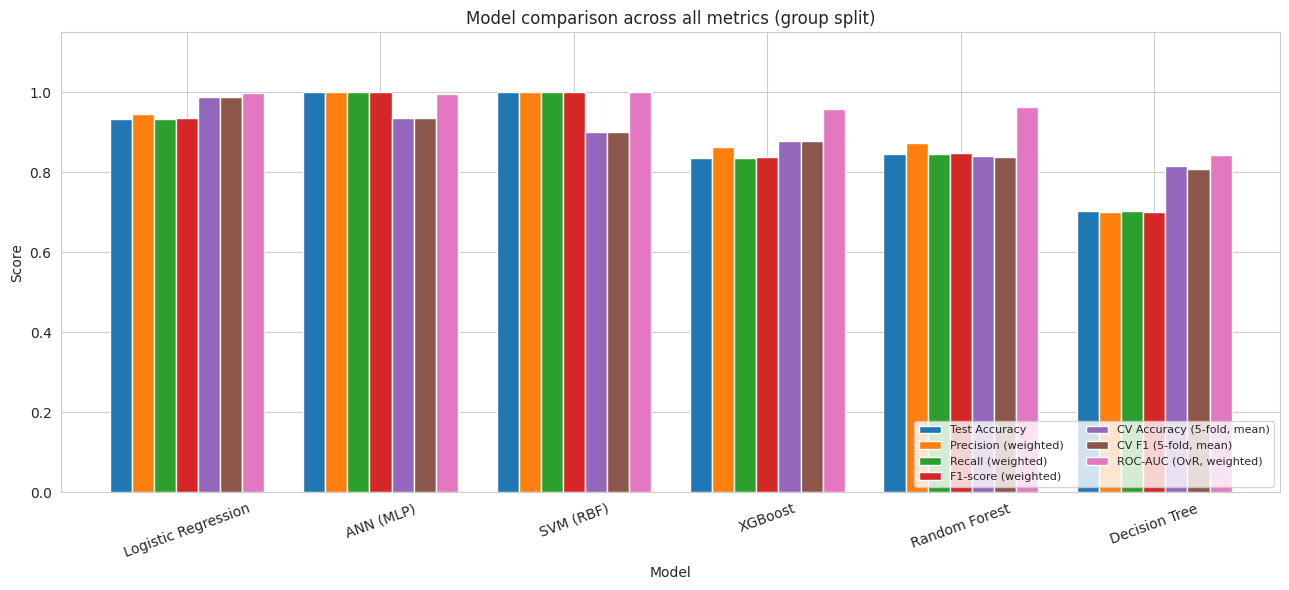

,Model,Best Params,Test Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),Train Accuracy,"CV Accuracy (5-fold, mean)","CV Accuracy (5-fold, std)","CV F1 (5-fold, mean)","CV F1 (5-fold, std)","ROC-AUC (OvR, weighted)"
0,Logistic Regression,"{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}",0.934,0.944,0.934,0.934,1.000,0.988,0.016,0.988,0.017,0.999
1,ANN (MLP),"{'learning_rate_init': 0.01, 'hidden_layer_siz...",1.000,1.000,1.000,1.000,0.996,0.935,0.050,0.935,0.050,0.995
2,SVM (RBF),"{'gamma': 0.01, 'C': 0.1}",1.000,1.000,1.000,1.000,1.000,0.901,0.097,0.901,0.094,1.000
3,XGBoost,"{'subsample': 1.0, 'n_estimators': 300, 'max_d...",0.835,0.864,0.835,0.839,1.000,0.879,0.091,0.878,0.090,0.957
4,Random Forest,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.846,0.874,0.846,0.849,1.000,0.842,0.113,0.839,0.115,0.964
5,Decision Tree,"{'min_samples_split': 2, 'min_samples_leaf': 1...",0.703,0.701,0.703,0.702,1.000,0.815,0.097,0.809,0.095,0.842


In [12]:
metric_cols = ['Test Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)',
               'CV Accuracy (5-fold, mean)', 'CV F1 (5-fold, mean)', 'ROC-AUC (OvR, weighted)']

fig, ax = plt.subplots(figsize=(13, 6))
plot_df = results_df.set_index('Model')[metric_cols]
plot_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Score')
ax.set_title('Model comparison across all metrics (group split)')
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.set_ylim(0, 1.15)
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

results_df.round(3)


### Train vs. Test accuracy (overfitting check)

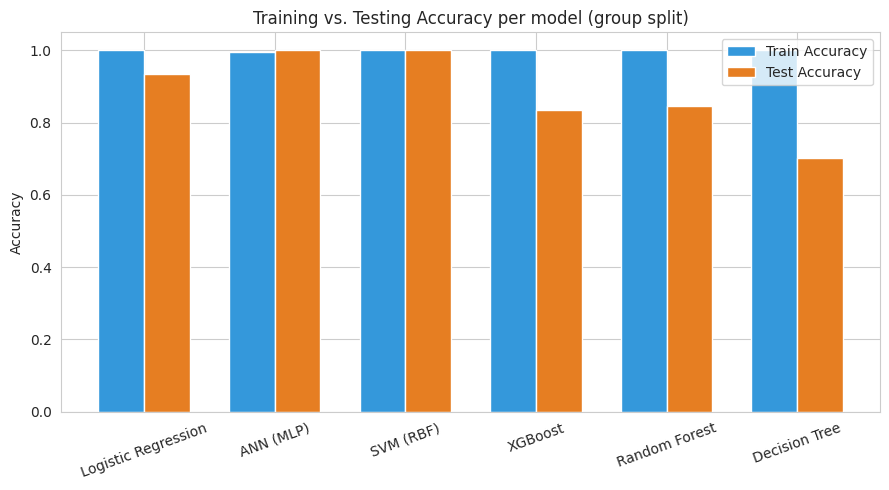

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,1.000000,0.934066
1,ANN (MLP),0.995556,1.000000
2,SVM (RBF),1.000000,1.000000
3,XGBoost,1.000000,0.835165
4,Random Forest,1.000000,0.846154
5,Decision Tree,1.000000,0.703297


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df)); w = 0.35
ax.bar(x - w/2, results_df['Train Accuracy'], width=w, label='Train Accuracy', color='#3498db')
ax.bar(x + w/2, results_df['Test Accuracy'], width=w, label='Test Accuracy', color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(results_df['Model'], rotation=20)
ax.set_ylabel('Accuracy'); ax.set_title('Training vs. Testing Accuracy per model (group split)')
ax.legend()
plt.tight_layout(); plt.show()

results_df[['Model', 'Train Accuracy', 'Test Accuracy']]


### Best model (by group-split CV F1)

In [14]:
best_row = results_df.iloc[0]
print("Best model (by CV F1, group split by SME, tuned + SMOTE):", best_row['Model'])
print("Best hyperparameters:", best_row['Best Params'])
results_df.drop(columns=['Best Params']).round(4)


Best model (by CV F1, group split by SME, tuned + SMOTE): Logistic Regression
Best hyperparameters: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.1}


,Model,Test Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted),Train Accuracy,"CV Accuracy (5-fold, mean)","CV Accuracy (5-fold, std)","CV F1 (5-fold, mean)","CV F1 (5-fold, std)","ROC-AUC (OvR, weighted)"
0,Logistic Regression,0.9341,0.9445,0.9341,0.9345,1.0000,0.9881,0.0162,0.9879,0.0167,0.9992
1,ANN (MLP),1.0000,1.0000,1.0000,1.0000,0.9956,0.9351,0.0498,0.9354,0.0504,0.9951
2,SVM (RBF),1.0000,1.0000,1.0000,1.0000,1.0000,0.9010,0.0969,0.9015,0.0944,1.0000
3,XGBoost,0.8352,0.8642,0.8352,0.8387,1.0000,0.8788,0.0908,0.8782,0.0897,0.9571
4,Random Forest,0.8462,0.8742,0.8462,0.8490,1.0000,0.8417,0.1134,0.8391,0.1151,0.9637
5,Decision Tree,0.7033,0.7007,0.7033,0.7018,1.0000,0.8147,0.0971,0.8092,0.0947,0.8420


## 9. Feature Importance (tree-based models)

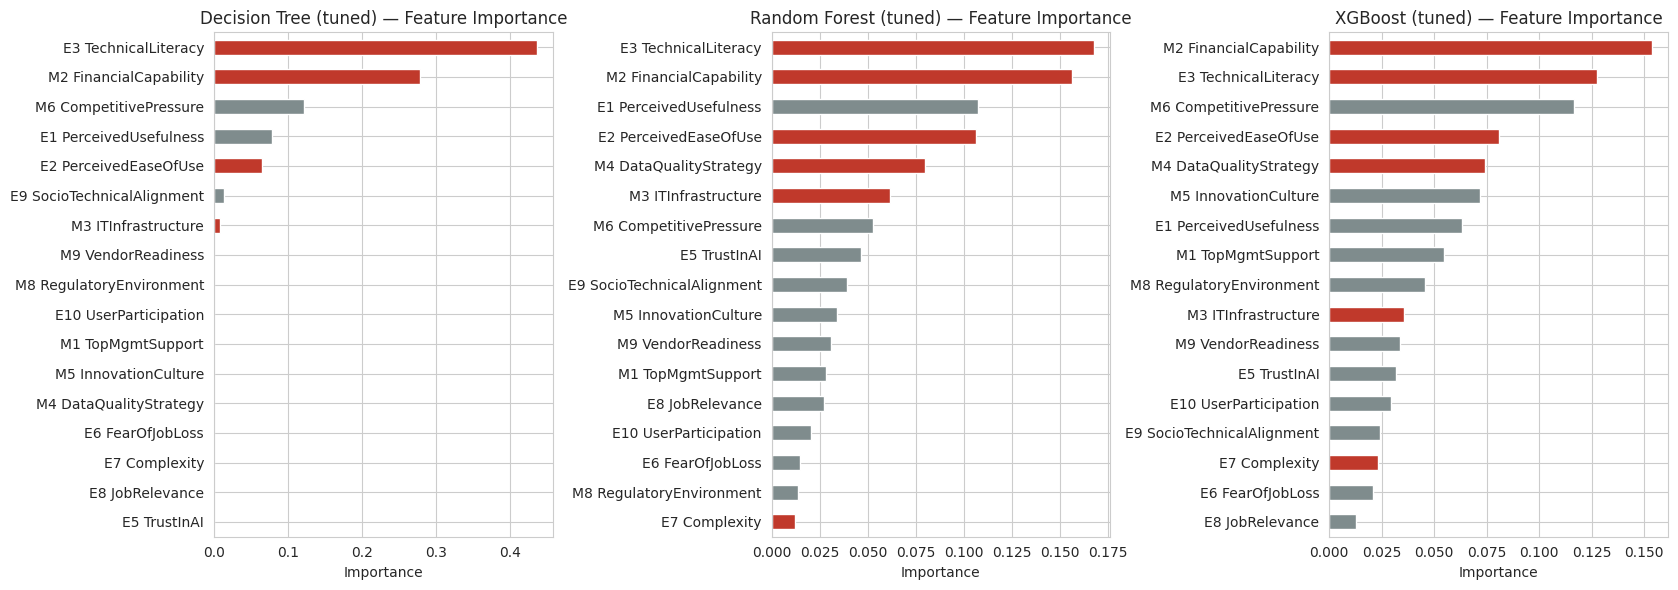

Red bars = priority factors (E2, E3, E7, M2, M3, M4)


In [15]:
tree_models = {k: v for k, v in best_estimators.items() if k in ['Decision Tree', 'Random Forest', 'XGBoost']}

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, (name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    colors = ['#c0392b' if f in PRIORITY_COLS else '#7f8c8d' for f in importances.index]
    importances.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'{name} (tuned) — Feature Importance')
    ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()
print("Red bars = priority factors (E2, E3, E7, M2, M3, M4)")


## 10. Explainability (SHAP) — Final Selected Model

`KernelExplainer` is model-agnostic, so this works regardless of which model type ends up ranked first (linear, kernel-based, or tree-based). The background is summarised to 20 representative points via k-means, and 100 samples are drawn per test point for tractability on this dataset size.

Explaining final selected model: Logistic Regression


  0%|          | 0/91 [00:00<?, ?it/s]

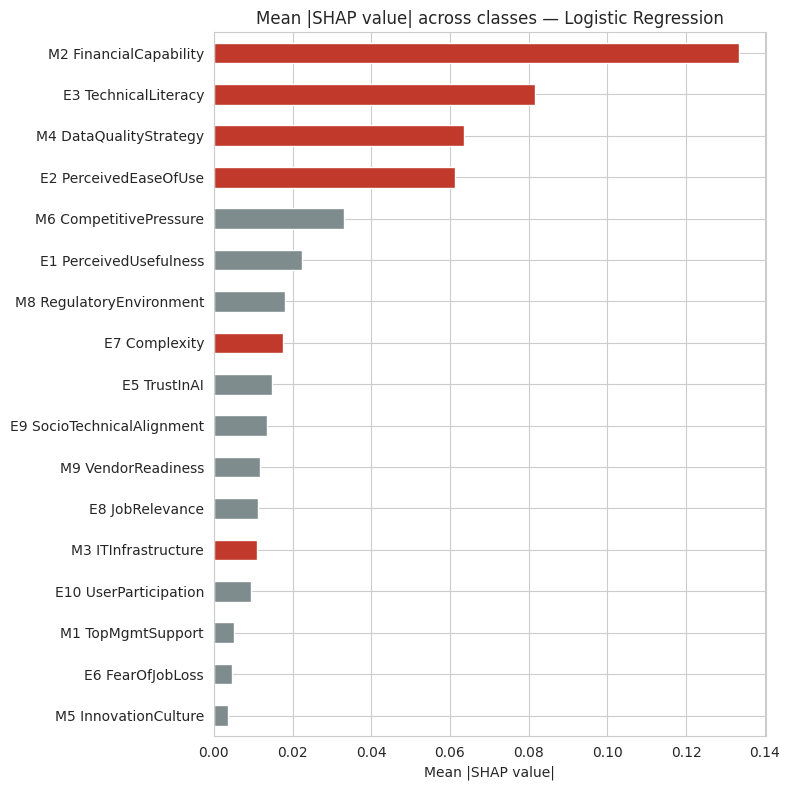

Red bars = Phase-1 priority factors (E2, E3, E7, M2, M3, M4)


,0
M2 FinancialCapability,0.1336
E3 TechnicalLiteracy,0.0815
M4 DataQualityStrategy,0.0637
E2 PerceivedEaseOfUse,0.0613
M6 CompetitivePressure,0.0330
E1 PerceivedUsefulness,0.0225
M8 RegulatoryEnvironment,0.0180
E7 Complexity,0.0175
E5 TrustInAI,0.0148
E9 SocioTechnicalAlignment,0.0135


In [16]:
best_name = results_df.iloc[0]['Model']
best_model = best_estimators[best_name]
print("Explaining final selected model:", best_name)

background = shap.kmeans(X_train_res, 20)
explainer = shap.KernelExplainer(best_model.predict_proba, background)
shap_values = explainer.shap_values(X_test, nsamples=100)

# Correctly calculate mean absolute SHAP values per feature, averaged across samples and classes
# Assuming shap_values is an ndarray of shape (n_samples, n_features, n_classes)
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
shap_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
colors = ['#c0392b' if f in PRIORITY_COLS else '#7f8c8d' for f in shap_importance.sort_values().index]
shap_importance.sort_values().plot(kind='barh', color=colors)
plt.title(f'Mean |SHAP value| across classes — {best_name}')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout(); plt.show()

print("Red bars = Phase-1 priority factors (E2, E3, E7, M2, M3, M4)")
shap_importance.round(4)